In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import EVTLibrary as evt
importlib.reload(evt)
from scipy import stats
from scipy.stats import genpareto
import matplotlib.patches as mpatches

In [2]:
u_prel = [0.041, 0.035, 0.042, 0.035, 0.045, 0.044, 0.046, 0.045, 0.040, 0.037]
loss_df = evt.get_data(start="2000-01-01", end="2026-03-31")
u, extreme_values = evt.get_extreme_data(u_prel, loss_df, False)

In [ ]:
def split_into_week_groups(df):
    temp = df.copy()

    temp["Weekday"] = temp.index.day_name()

    groups = {
        "mån-tis": ["Monday", "Tuesday"],
        "ons-fre": ["Wednesday", "Thursday", "Friday"]
    }

    result = {}
    for group_name, days in groups.items():
        result[group_name] = temp[temp["Weekday"].isin(days)].copy()

    return result

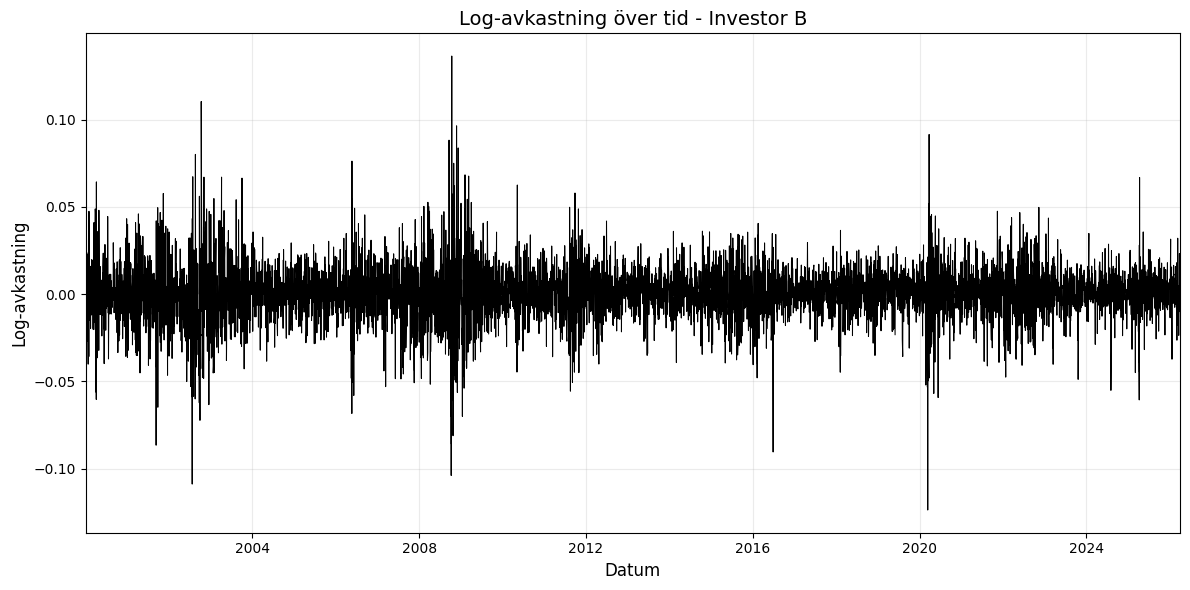

In [3]:
df = yf.download("INVE-B.ST", start="2000-01-01", end="2026-03-31", interval="1d", auto_adjust=True, progress=False)

df_clean = df[df["Volume"] > 0].copy()
df_clean["lgr"] = np.log(df["Close"]).diff()

series = df_clean["lgr"]
plt.figure(figsize=(12, 6))
plt.plot(series.index, series.values, linewidth=0.75, color = "black")

plt.title("Log-avkastning över tid - Investor B", fontsize=14)
plt.xlabel("Datum", fontsize = 12)
plt.ylabel("Log-avkastning", fontsize = 12)

plt.xlim(series.index[0], series.index[-1])
plt.grid(True, alpha = 0.25)
plt.tight_layout()
plt.show()

## Extraherar resultat för samtliga aktier

### Tabell för överskridandesannolikhet uppdelat mellan aktier och veckogrupp

In [4]:
cluster_maxima, clustered_exceedances = evt.get_cluster_maxima(u, extreme_values, r=15)

week_groups = ["mån-tis", "ons-fre"]
declustered_by_week_group = {}
total_declustered_by_week_group = {}
total_loss_by_week_group = {}

for stock in loss_df.columns:
    declustered_by_week_group[stock] = evt.split_into_week_groups(cluster_maxima[stock])
    total_declustered_by_week_group[stock] = {group: len(declustered_by_week_group[stock][group]) for group in week_groups}

    loss_by_week_group = evt.split_into_week_groups(loss_df[[stock]].dropna())
    total_loss_by_week_group[stock] = {group: len(loss_by_week_group[group]) for group in week_groups}

total_declustered_by_week_group = pd.DataFrame(total_declustered_by_week_group)
total_loss_by_week_group = pd.DataFrame(total_loss_by_week_group)

declustered_proportions_by_week_group = (total_declustered_by_week_group / total_loss_by_week_group).round(4)


In [5]:
rows = []

alpha = 0.05
m = len(loss_df.columns)  # antal aktier/tester

for stock in loss_df.columns:
    # Antal exceedances i respektive grupp
    K1 = total_declustered_by_week_group[stock]["mån-tis"]
    K2 = total_declustered_by_week_group[stock]["ons-fre"]

    # Totalt antal observationer i respektive grupp
    n1 = total_loss_by_week_group[stock]["mån-tis"]
    n2 = total_loss_by_week_group[stock]["ons-fre"]

    # Exceedance rates
    lambda1 = K1 / n1
    lambda2 = K2 / n2

    # Poolad proportion under H0
    lambda_pooled = (K1 + K2) / (n1 + n2)

    # Standard error för tvåproportioners z-test
    pooled_variance = lambda_pooled * (1 - lambda_pooled) * ((1 / n1) + (1 / n2))
    se = np.sqrt(pooled_variance)

    z_stat = (lambda1 - lambda2) / se
    pval = stats.norm.sf(abs(z_stat)) * 2

    rows.append({
        "Aktie": stock,
        "K mån-tis": K1,
        "n mån-tis": n1,
        "Frekvens mån-tis": lambda1,
        "K ons-fre": K2,
        "n ons-fre": n2,
        "Frekvens ons-fre": lambda2,
        "Skillnad": lambda1 - lambda2,
        "SE": se,
        "z-stat": z_stat,
        "p-värde": pval,
        "Signifikant": pval < alpha,
        "Signifikant Bonferroni": pval < alpha / m
    })

ztest_table = pd.DataFrame(rows)

display(ztest_table)

,Aktie,K mån-tis,n mån-tis,Frekvens mån-tis,K ons-fre,n ons-fre,Frekvens ons-fre,Skillnad,SE,z-stat,p-värde,Signifikant,Signifikant Bonferroni
0,Kinnevik B,38,2399,0.015840,50,3593,0.013916,0.001924,0.003172,0.606620,0.544103,False,False
1,Investor B,32,2399,0.013339,25,3593,0.006958,0.006381,0.002559,2.493245,0.012658,True,False
2,SEB A,24,2399,0.010004,46,3593,0.012803,-0.002799,0.002833,-0.987807,0.323247,False,False
3,Nordea Bank,28,2399,0.011672,47,3593,0.013081,-0.001409,0.002931,-0.480841,0.630630,False,False
4,Castellum,27,2399,0.011255,22,3593,0.006123,0.005132,0.002374,2.161164,0.030683,True,False
5,Skanska B,17,2399,0.007086,44,3593,0.012246,-0.005160,0.002647,-1.949527,0.051233,False,False
6,ABB,20,2399,0.008337,31,3593,0.008628,-0.000291,0.002422,-0.120179,0.904341,False,False
7,Atlas Copco A,28,2399,0.011672,31,3593,0.008628,0.003044,0.002603,1.169123,0.242354,False,False
8,Boliden,56,2399,0.023343,73,3593,0.020317,0.003026,0.003827,0.790700,0.429119,False,False
9,SCA B,25,2399,0.010421,34,3593,0.009463,0.000958,0.002603,0.368050,0.712836,False,False


In [6]:
week_groups = ["mån-tis", "ons-fre"]

gpd_dict = {}
excesses = {}
rows = []

for stock in loss_df.columns:
    gpd_dict[stock] = {}
    excesses[stock] = {}

    for group in week_groups:
        y = (declustered_by_week_group[stock][group]["Loss"] - u[stock]).dropna()

        excesses[stock][group] = y
        xi_hat, loc_hat, sigma_hat = stats.genpareto.fit(y, floc=0)
        gpd_dict[stock][group] = (xi_hat, loc_hat, sigma_hat)

        rows.append({
            "Aktie": stock,
            "Grupp": group,
            "n": len(y),
            "xi_hat": xi_hat,
            "sigma_hat": sigma_hat
        })

gpd_table = pd.DataFrame(rows)

gpd_wide = gpd_table.pivot(
    index="Aktie",
    columns="Grupp",
    values=["n", "xi_hat", "sigma_hat"]
)

gpd_wide = gpd_wide.swaplevel(axis=1).sort_index(axis=1)
display(gpd_wide)

Grupp         mån-tis                     ons-fre                    
                    n sigma_hat    xi_hat       n sigma_hat    xi_hat
Aktie                                                                
ABB              20.0  0.020378  0.616715    31.0  0.013690  0.459024
Atlas Copco A    28.0  0.018641 -0.048158    31.0  0.022988 -0.070567
Boliden          56.0  0.019996  0.182726    73.0  0.016691  0.463968
Castellum        27.0  0.020026 -0.079008    22.0  0.013925  0.117037
Investor B       32.0  0.010089  0.101763    25.0  0.013913  0.276719
Kinnevik B       38.0  0.019690  0.260303    50.0  0.029176  0.153529
Nordea Bank      28.0  0.022516 -0.033230    47.0  0.020569  0.018630
SCA B            25.0  0.008011  0.459689    34.0  0.015963  0.067621
SEB A            24.0  0.022036  0.285110    46.0  0.012735  0.386773
Skanska B        17.0  0.019564 -0.100442    44.0  0.014752  0.381996

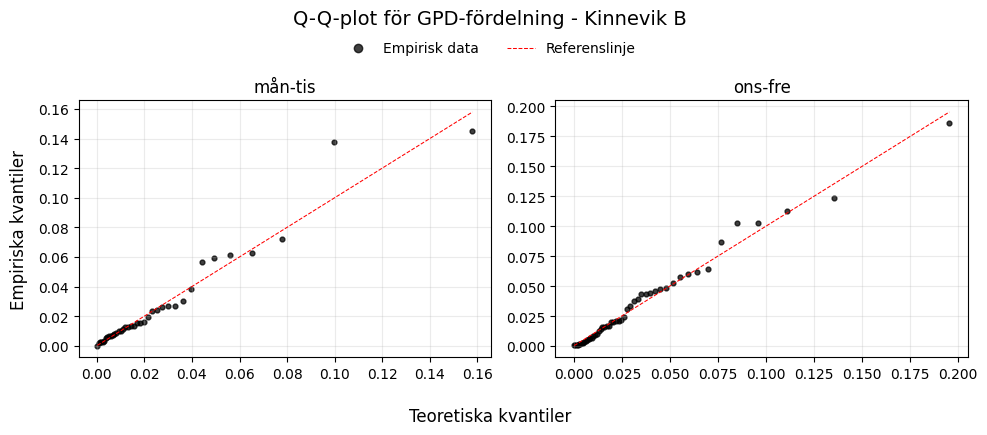

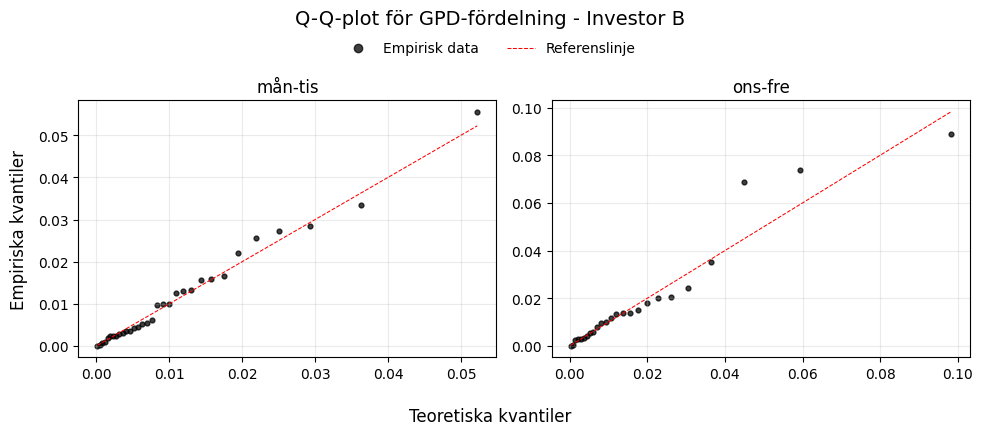

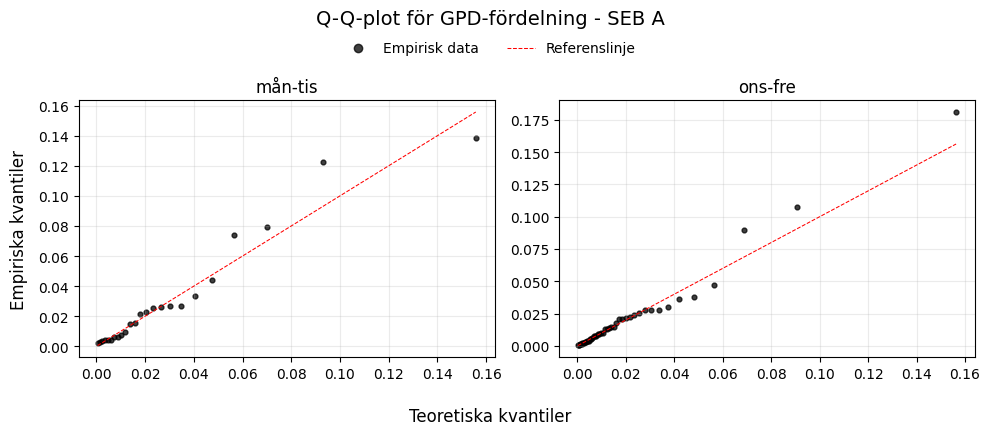

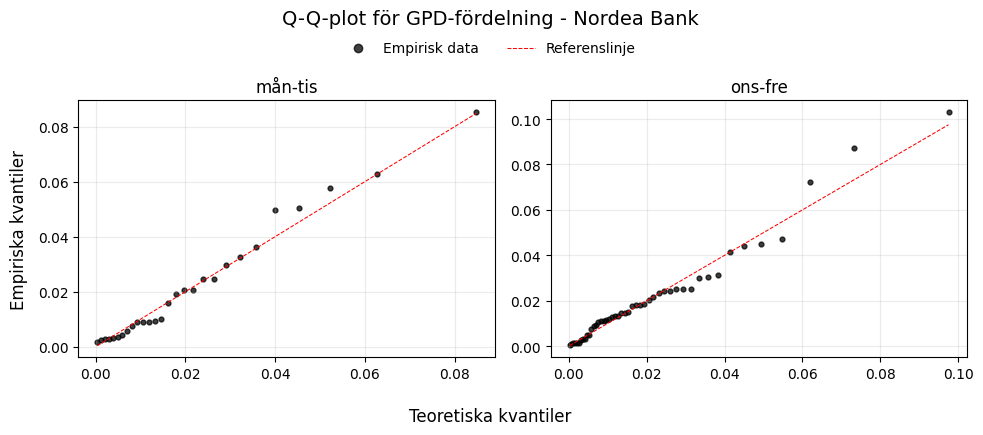

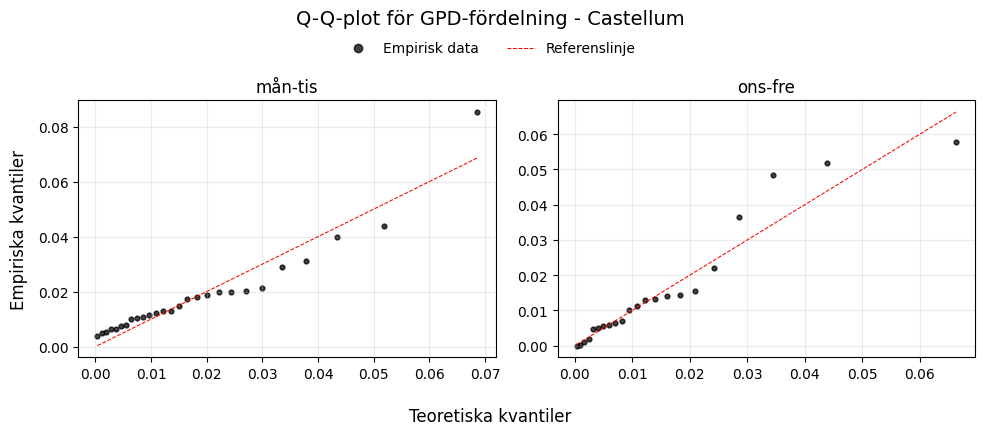

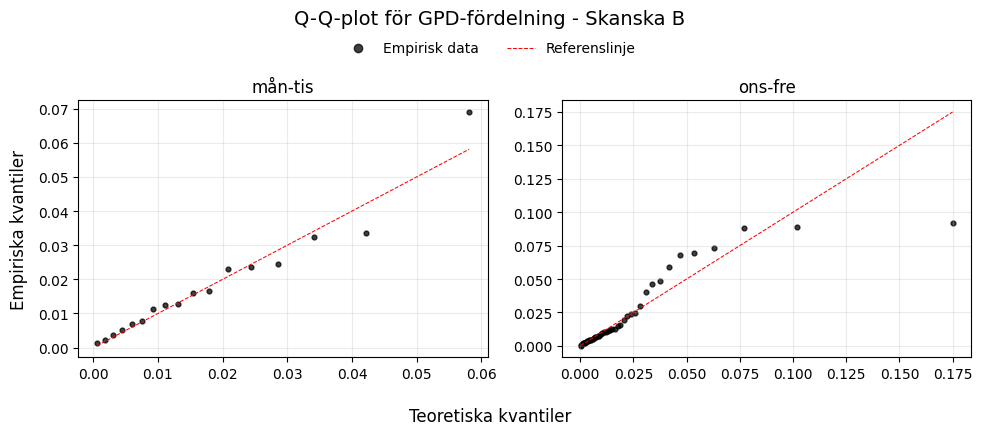

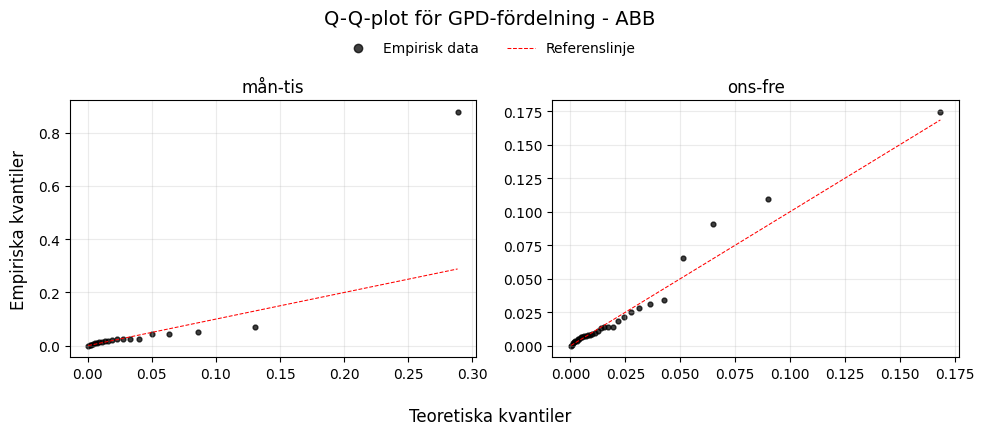

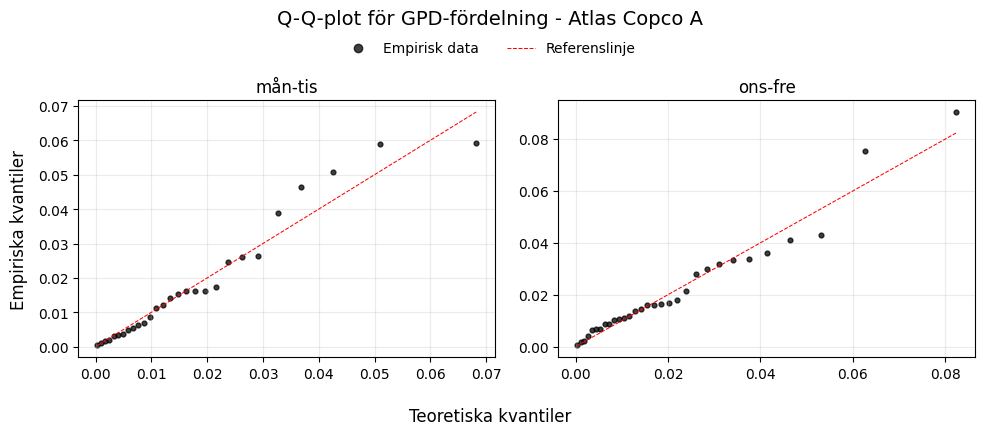

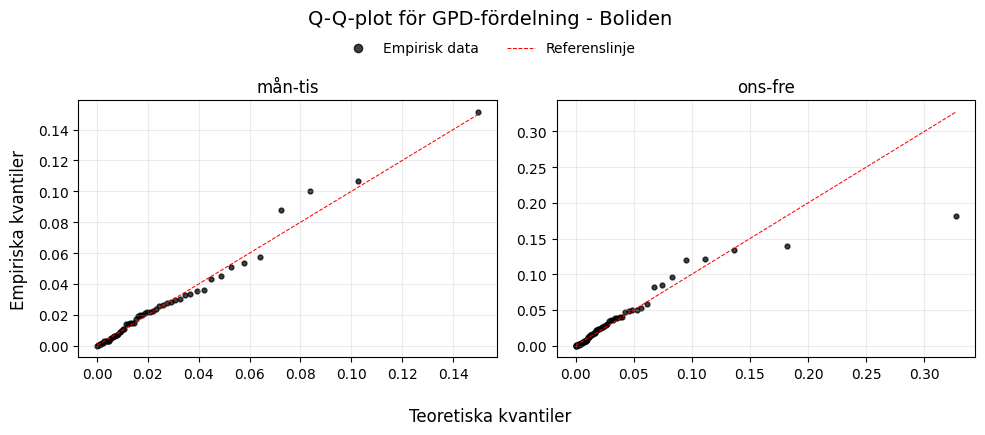

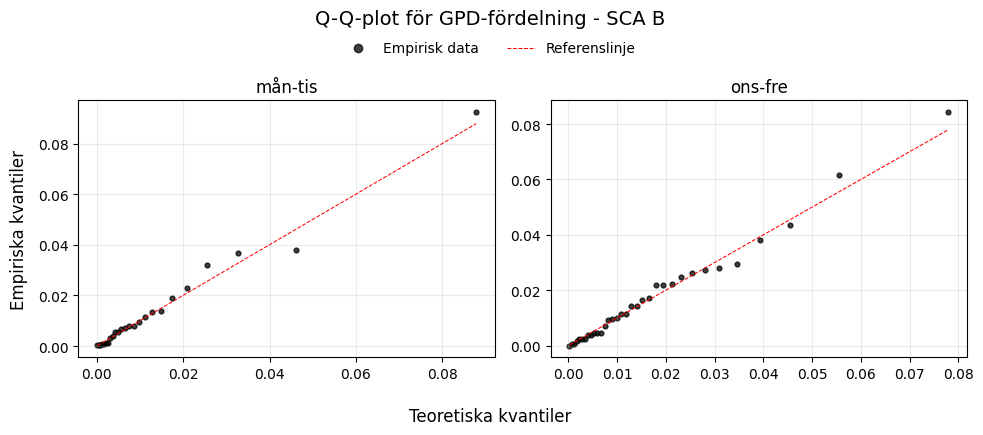

In [7]:
for stock in loss_df.columns:

    ncols = min(2, len(week_groups))
    nrows = int(np.ceil(len(week_groups) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, group in enumerate(week_groups):
        ax = axes[i]

        data = np.asarray(excesses[stock][group], dtype=float)
        sorted_data = np.sort(data)

        n = len(sorted_data)

        xi = gpd_dict[stock][group][0]
        sigma = gpd_dict[stock][group][2]

        p = (np.arange(1, n + 1) - 0.5) / n
        theoretical_q = stats.genpareto.ppf(p, c=xi, loc=0, scale=sigma)

        ax.scatter(theoretical_q, sorted_data, s=12, color="black", alpha=0.75)
        ax.plot(theoretical_q, theoretical_q, color="red", linestyle="--", linewidth=0.75)

        ax.set_title(f"{group}", fontsize=12)
        ax.grid(True, alpha=0.25)

    for j in range(len(week_groups), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], color="red", linestyle="--", label="Referenslinje", linewidth=0.75)
    ]

    fig.legend(handles=handles, loc='upper center',
               bbox_to_anchor=(0.5, 1.00), ncol=2, frameon=False)
    fig.suptitle(f"Q-Q-plot för GPD-fördelning - {stock}", y=1.05, fontsize=14)
    fig.supxlabel("Teoretiska kvantiler", fontsize=12)
    fig.supylabel("Empiriska kvantiler", fontsize=12)

    plt.tight_layout()
    plt.show()

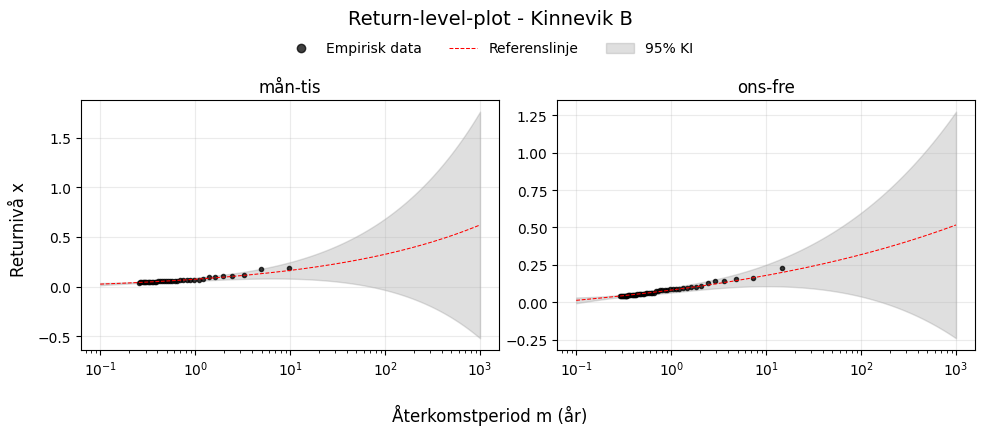

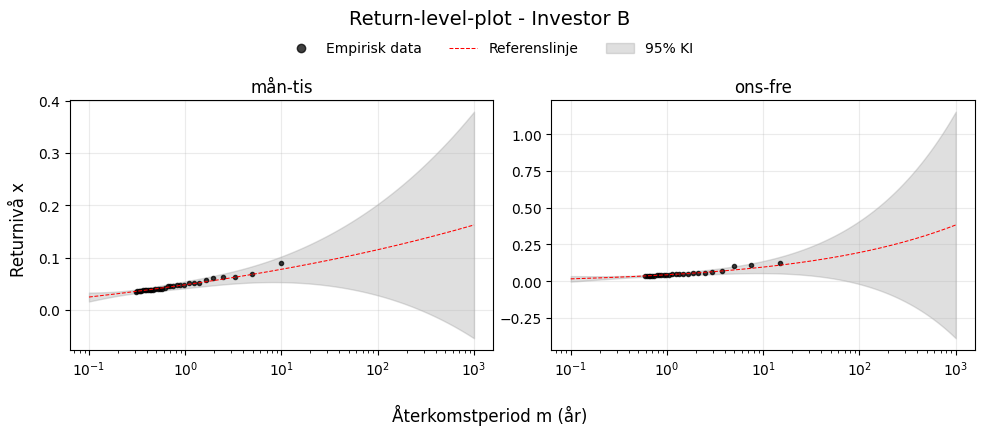

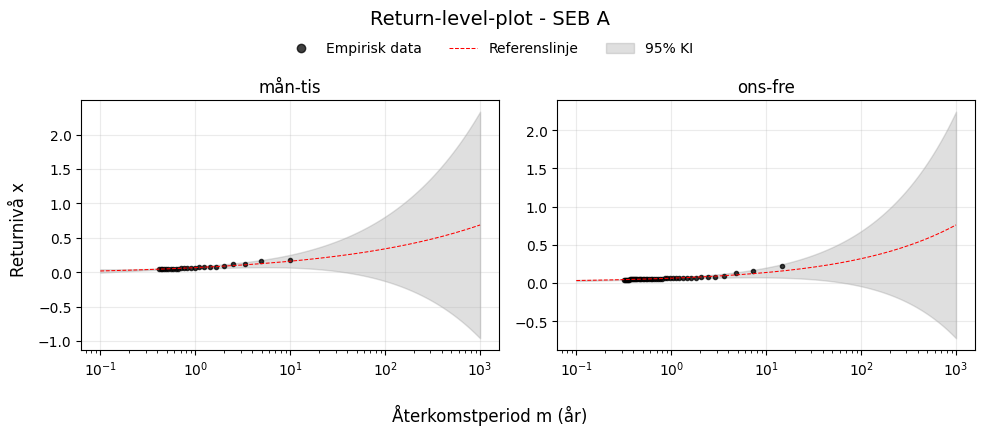

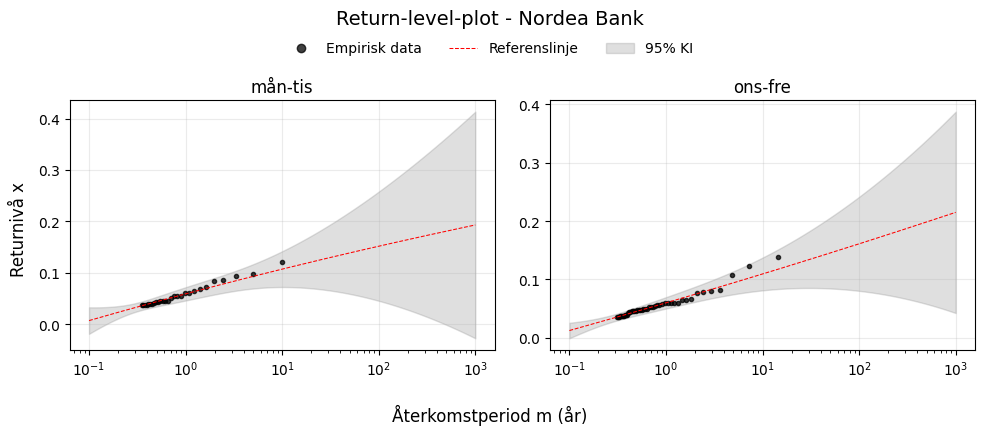

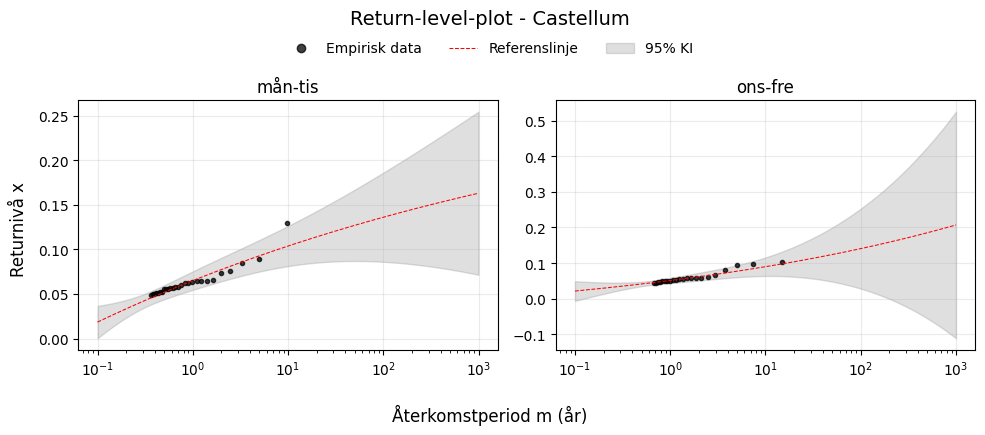

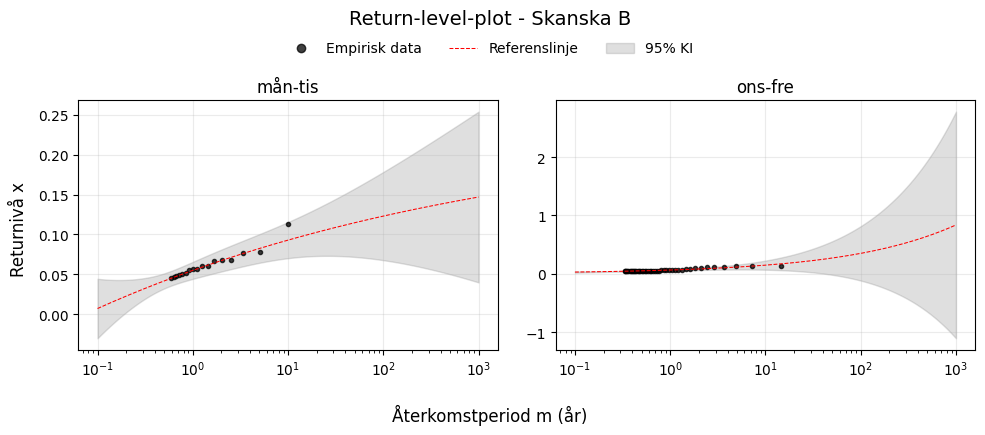

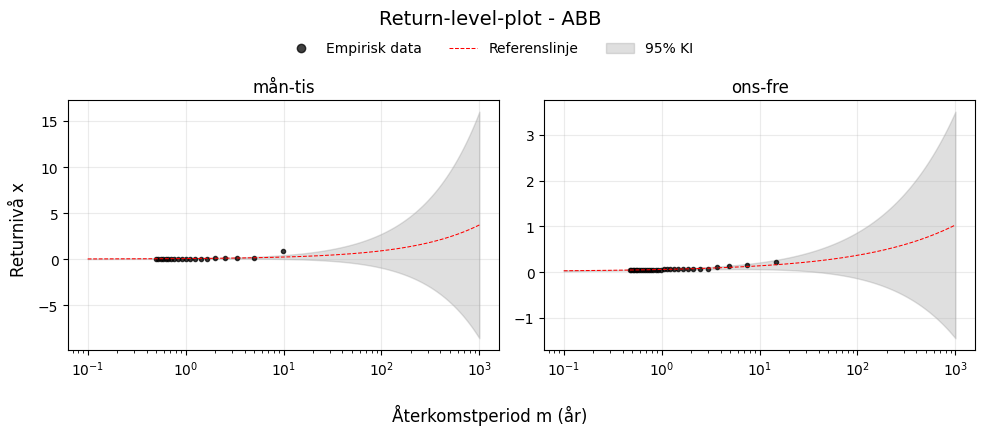

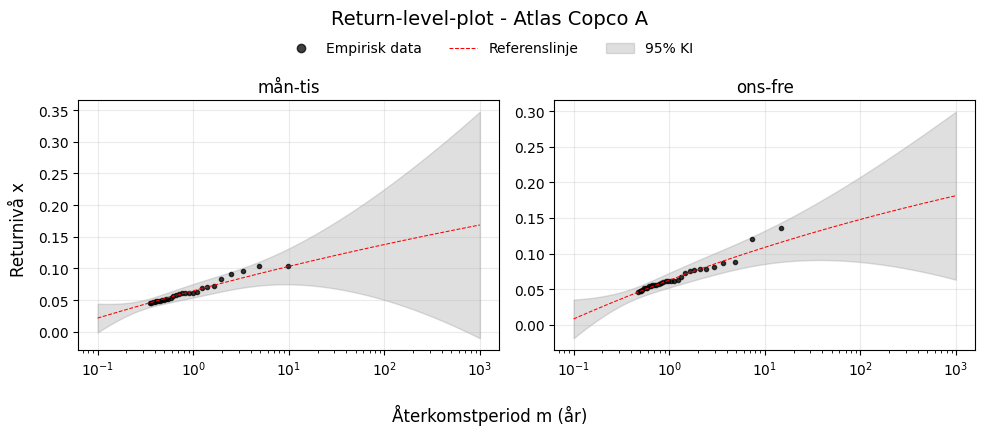

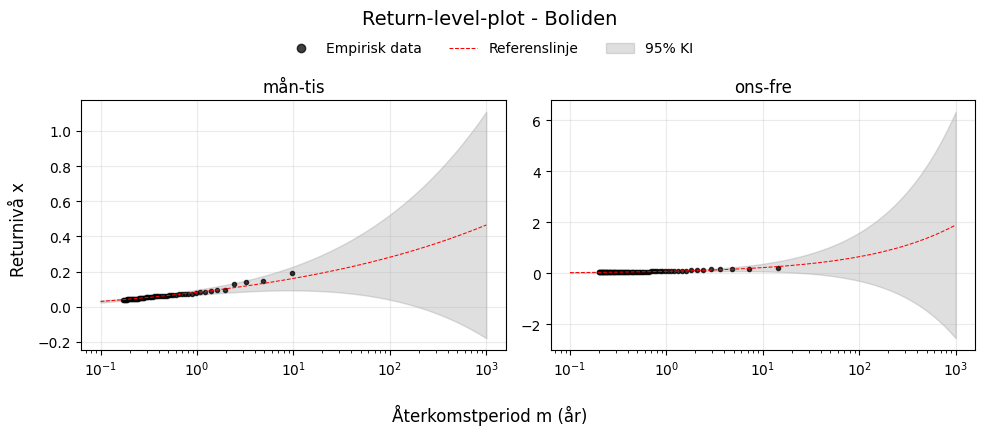

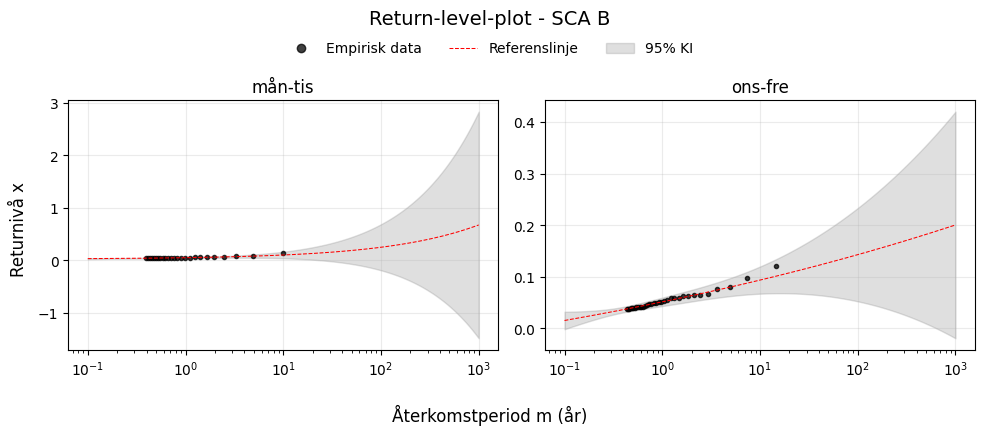

In [8]:
cov_dict = {}

for stock in loss_df.columns:

    cov_dict[stock] = {}

    ncols = min(2, len(week_groups))
    nrows = int(np.ceil(len(week_groups) / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for i, group in enumerate(week_groups):
        ax = axes[i]

        y = excesses[stock][group]
        y_arr = np.asarray(y, dtype=float)

        xi_hat = gpd_dict[stock][group][0]
        sigma_hat = gpd_dict[stock][group][2]

        k_exc = len(y_arr)
        n = total_loss_by_week_group[stock][group]
        rate = k_exc / n

        y_sorted = np.sort(y_arr)
        x_sorted = u[stock] + y_sorted

        ranks = np.arange(1, k_exc + 1)
        p_tail = (k_exc + 1 - ranks) / (k_exc + 1)
        m_emp = 1 / (p_tail * rate)

        ax.semilogx(m_emp / 252, x_sorted, 'o', markersize=3, color="black", alpha=0.75)

        cov_dict[stock][group] = evt.gpd_cov_matrix(y_arr, sigma_hat, xi_hat)

        m_max_years = 1000
        m_grid = np.logspace(np.log10(0.1 * 252), np.log10(m_max_years * 252), 200)

        x_th = np.array([evt.return_level_hat(u[stock], sigma_hat, xi_hat, rate, m) for m in m_grid])

        # standard errors
        se = np.array([evt.return_level_se(u[stock], sigma_hat, xi_hat, rate, n, cov_dict[stock][group], m) for m in m_grid])

        ax.semilogx(m_grid / 252, x_th, '--', color = "red", linewidth = 0.75)
        ax.fill_between(m_grid / 252, x_th - 1.96 * se, x_th + 1.96 * se, color="gray", alpha=0.25)

        ax.set_title(f"{group}", fontsize=12)
        ax.grid(True, alpha=0.25)

    for j in range(len(week_groups), len(axes)):
        fig.delaxes(axes[j])

    handles = [
        plt.Line2D([], [], marker='o', linestyle='None', color='black', alpha=0.75, label="Empirisk data"),
        plt.Line2D([], [], color='red', linestyle='--', label="Referenslinje", linewidth=0.75),
        mpatches.Patch(color="gray", alpha=0.25, label="95% KI")
    ]

    fig.legend(handles=handles, loc='upper center',bbox_to_anchor=(0.5, 1.00), ncol=3, frameon=False)
    fig.suptitle(f"Return-level-plot - {stock}", y=1.05, fontsize=14)
    fig.supxlabel("Återkomstperiod m (år)", fontsize=12)
    fig.supylabel("Returnivå x", fontsize=12)

    plt.tight_layout()
    plt.show()